# Notebook 04: Seasonal Patterns & The Texas Rhythm

**One Sensor, One Year — Edition 2: Texas Grid**

India's grid breathes with the monsoon. Texas's grid breathes with temperature — and with the sun and wind patterns that track the calendar. Let's find the rhythm.

- Monthly stacked mix (MWh and % share)
- Four seasonal regimes: winter / spring / summer / fall
- Summer peak: the AC-driven gas surge
- Winter stress: cold-snap ramps
- **Diurnal solar shape by month** (the hourly data from N01 earns its keep here)
- Monthly emissions intensity

**Inputs:**
- `../data/processed/texas_2025_derived.csv` (from notebook 03 — has emissions columns)
- `../data/processed/texas_2025_hourly.csv` (from notebook 01 — 8,760 hours)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

PROCESSED = Path('../data/processed')

daily = pd.read_csv(PROCESSED / 'texas_2025_derived.csv', parse_dates=['Date'], index_col='Date')
hourly = pd.read_csv(PROCESSED / 'texas_2025_hourly.csv', parse_dates=['timestamp'], index_col='timestamp')

print(f'Daily: {len(daily)} rows, {len(daily.columns)} cols')
print(f'Hourly: {len(hourly)} rows, {len(hourly.columns)} cols')

daily['month'] = daily.index.month
hourly['month'] = hourly.index.month
hourly['hour'] = hourly.index.hour

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fuel_colors = {
    'coal':      '#D4890E',
    'gas':       '#E8A94A',
    'gas_cc':    '#F0C078',
    'gas_total': '#F0C078',
    'nuclear':   '#2A9D8F',
    'hydro':     '#264653',
    'wind':      '#72B352',
    'solar':     '#F4C430',
    'biomass':   '#8B6F47',
    'other':     '#9B72CF',
}
fuel_labels = {
    'coal': 'Coal', 'gas_total': 'Gas (all)', 'nuclear': 'Nuclear',
    'hydro': 'Hydro', 'wind': 'Wind', 'solar': 'Solar',
    'biomass': 'Biomass', 'other': 'Other',
}

Daily: 365 rows, 23 cols
Hourly: 8760 rows, 12 cols


## 1. Monthly stacked mix — MWh

Averaged daily generation per month, stacked by fuel. First look at how the mix shifts month to month.

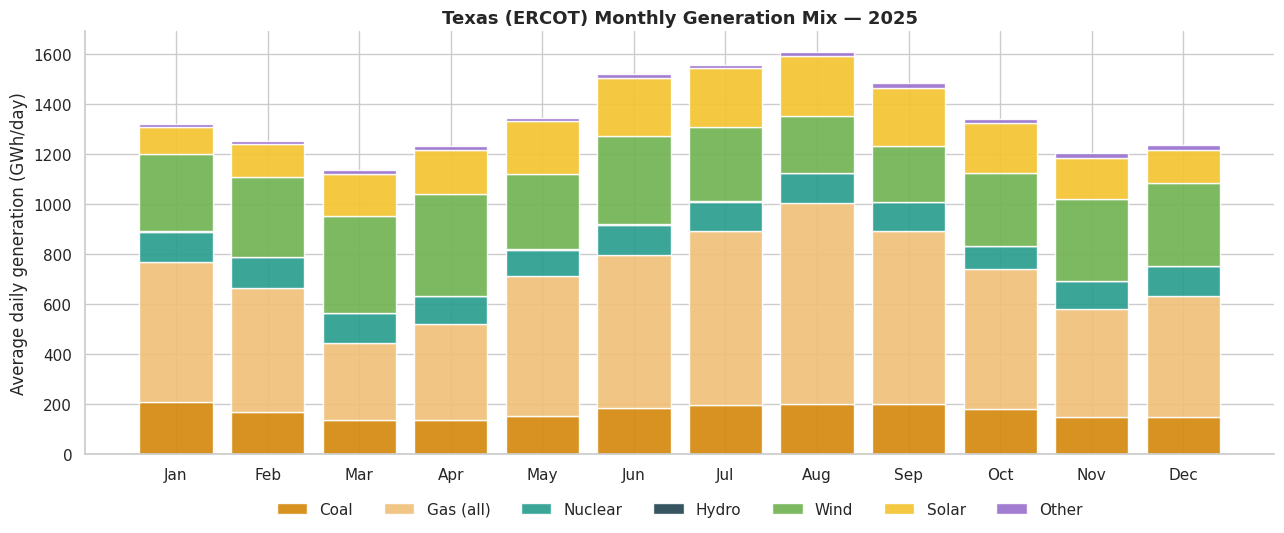

In [2]:
stack_order = ['coal', 'gas_total', 'nuclear', 'hydro', 'wind', 'solar', 'other']
monthly = daily.groupby('month')[stack_order].mean()

fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(12)
for col in stack_order:
    vals = monthly[col].values / 1e3  # → GWh/day
    ax.bar(MONTH_NAMES, vals, bottom=bottom,
           color=fuel_colors[col], label=fuel_labels[col], alpha=0.92, width=0.8)
    bottom += vals

ax.set_ylabel('Average daily generation (GWh/day)')
ax.set_title('Texas (ERCOT) Monthly Generation Mix — 2025',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=7, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## 2. Monthly share — normalized to %

Same story, but every month normalized to 100% so we can read share shifts without generation volume confusing the picture.

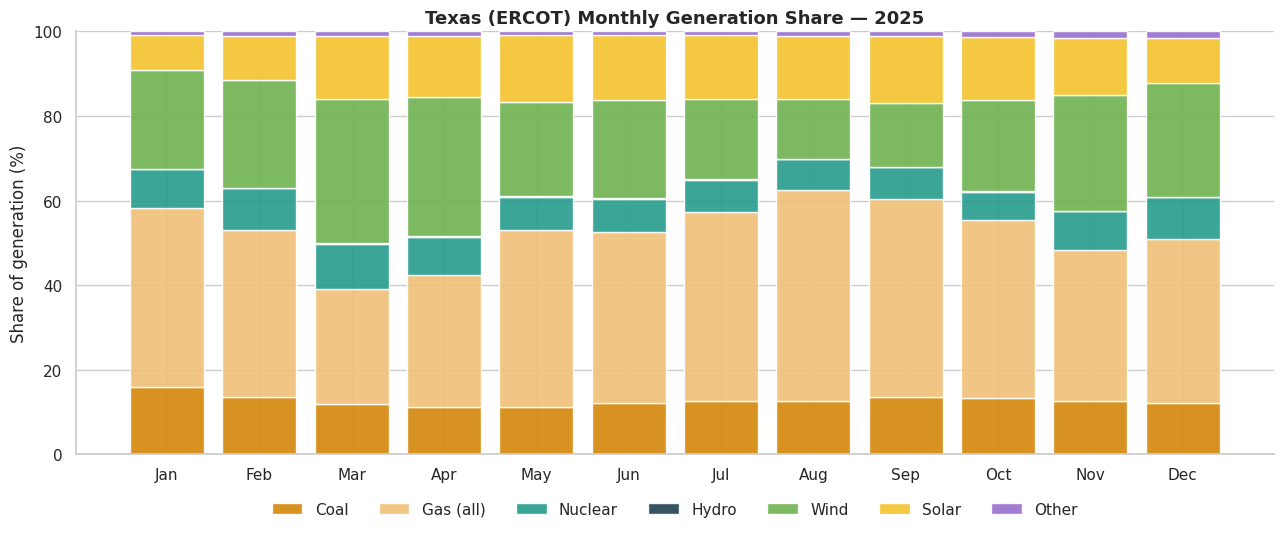

Wind share by month:
  Jan:  23.4%
  Feb:  25.6%
  Mar:  34.2%
  Apr:  33.0%
  May:  22.2%
  Jun:  23.3%
  Jul:  19.0%
  Aug:  14.2%
  Sep:  15.2%
  Oct:  21.6%
  Nov:  27.4%
  Dec:  26.9%

Gas (all) share by month:
  Jan:  42.3%
  Feb:  39.5%
  Mar:  27.1%
  Apr:  31.1%
  May:  41.7%
  Jun:  40.4%
  Jul:  44.7%
  Aug:  49.8%
  Sep:  46.8%
  Oct:  41.9%
  Nov:  35.9%
  Dec:  38.9%


In [3]:
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5.5))
bottom = np.zeros(12)
for col in stack_order:
    vals = monthly_pct[col].values
    ax.bar(MONTH_NAMES, vals, bottom=bottom,
           color=fuel_colors[col], label=fuel_labels[col], alpha=0.92, width=0.8)
    bottom += vals

ax.set_ylabel('Share of generation (%)')
ax.set_title('Texas (ERCOT) Monthly Generation Share — 2025',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=7, frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

# Print the shift in wind and gas across months
print('Wind share by month:')
for i, m in enumerate(MONTH_NAMES):
    print(f'  {m}: {monthly_pct["wind"].iloc[i]:5.1f}%')
print('\nGas (all) share by month:')
for i, m in enumerate(MONTH_NAMES):
    print(f'  {m}: {monthly_pct["gas_total"].iloc[i]:5.1f}%')

## 3. The four seasonal regimes

Collapse the year into four meteorological seasons and read the mix off directly.

In [4]:
SEASONS = {
    'Winter (Dec-Feb)':  [12, 1, 2],
    'Spring (Mar-May)':  [3, 4, 5],
    'Summer (Jun-Aug)':  [6, 7, 8],
    'Fall   (Sep-Nov)':  [9, 10, 11],
}

print(f'Seasonal average daily generation (GWh/day) and shares')
print('=' * 100)
hdr = f'{"Season":<22s}' + ''.join(f'{fuel_labels[f]:>10s}' for f in stack_order) + f'{"Total":>10s}' + f'{"Clean%":>9s}'
print(hdr)
print('-' * 100)

for name, mlist in SEASONS.items():
    mask = daily['month'].isin(mlist)
    avg = daily.loc[mask, stack_order].mean() / 1e3
    total = avg.sum()
    clean = (avg['nuclear'] + avg['hydro'] + avg['wind'] + avg['solar']) / total * 100
    row = f'{name:<22s}' + ''.join(f'{v:>10.1f}' for v in avg.values) + f'{total:>10.1f}' + f'{clean:>8.1f}%'
    print(row)

Seasonal average daily generation (GWh/day) and shares
Season                      Coal Gas (all)   Nuclear     Hydro      Wind     Solar     Other     Total   Clean%
----------------------------------------------------------------------------------------------------
Winter (Dec-Feb)           177.4     511.9     122.3       0.9     320.5     123.3      14.9    1271.3    44.6%
Spring (Mar-May)           142.3     417.8     112.8       2.1     364.5     185.2      13.1    1237.7    53.7%
Summer (Jun-Aug)           194.3     705.1     119.5       2.5     292.4     235.3      14.8    1563.8    41.5%
Fall   (Sep-Nov)           177.0     563.1     104.8       0.5     281.8     198.1      18.0    1343.3    43.6%


## 4. Summer peak — the AC surge

July–August is when Texas load peaks as air conditioning runs flat out. The question for the story: does gas pick up the peak, or do solar and wind carry it?

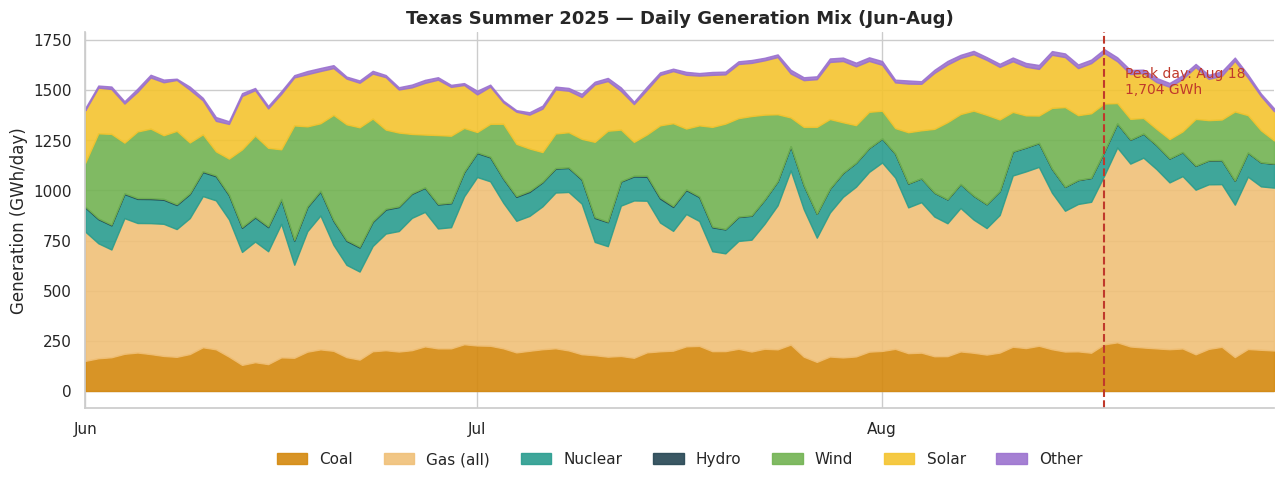


Summer peak day: Monday August 18
  Total: 1,704 GWh
  Coal        :   232.4 GWh ( 13.6%)
  Gas (all)   :   841.3 GWh ( 49.4%)
  Nuclear     :   118.8 GWh (  7.0%)
  Hydro       :     1.2 GWh (  0.1%)
  Wind        :   239.5 GWh ( 14.1%)
  Solar       :   251.6 GWh ( 14.8%)
  Other       :    19.5 GWh (  1.1%)


In [5]:
summer = daily.loc['2025-06-01':'2025-08-31']
peak_day = summer[stack_order].sum(axis=1).idxmax()

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(summer))
for col in stack_order:
    vals = summer[col].values / 1e3
    ax.fill_between(summer.index, bottom, bottom + vals,
                    color=fuel_colors[col], label=fuel_labels[col], alpha=0.9)
    bottom += vals

ax.axvline(peak_day, color='#C0392B', linestyle='--', linewidth=1.5)
ax.annotate(
    f'Peak day: {peak_day.strftime("%b %d")}\n{summer.loc[peak_day, stack_order].sum()/1e3:,.0f} GWh',
    xy=(peak_day, bottom.max() * 0.95),
    xytext=(15, 0), textcoords='offset points',
    fontsize=10, color='#C0392B',
    va='top',
)

ax.set_ylabel('Generation (GWh/day)')
ax.set_title('Texas Summer 2025 — Daily Generation Mix (Jun-Aug)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=7, frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.set_xlim(summer.index.min(), summer.index.max())
sns.despine()
plt.tight_layout()
plt.show()

peak_mix = summer.loc[peak_day, stack_order]
peak_total = peak_mix.sum()
print(f'\nSummer peak day: {peak_day.strftime("%A %B %d")}')
print(f'  Total: {peak_total/1e3:,.0f} GWh')
for fuel in stack_order:
    pct = peak_mix[fuel] / peak_total * 100
    print(f'  {fuel_labels[fuel]:12s}: {peak_mix[fuel]/1e3:7.1f} GWh ({pct:5.1f}%)')

## 5. Winter stress — cold snaps

Cold snaps drive heating load spikes and create wholesale-price-crushing ramps on gas-CC and simple-cycle gas. 2025 Texas winter is where we'd find them if any. Mark the peak gas day of the winter window.

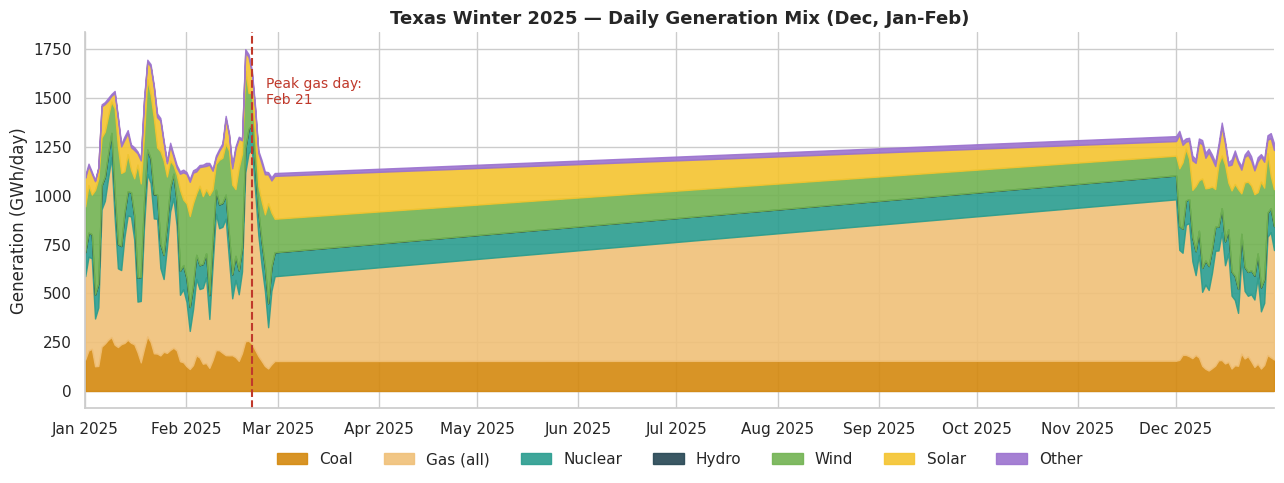


Winter peak gas day: Friday February 21
  Gas (all):  995.0 GWh
  Coal:       241.7 GWh
  Wind:       163.5 GWh
  Intensity:  0.401 tCO2/MWh


In [7]:
winter_mask = daily['month'].isin([12, 1, 2])
winter = daily.loc[winter_mask].sort_index()
winter_peak_gas = winter['gas_total'].idxmax()

fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(winter))
for col in stack_order:
    vals = winter[col].values / 1e3
    ax.fill_between(winter.index, bottom, bottom + vals,
                    color=fuel_colors[col], label=fuel_labels[col], alpha=0.9)
    bottom += vals

ax.axvline(winter_peak_gas, color='#C0392B', linestyle='--', linewidth=1.5)
ax.annotate(
    f'Peak gas day:\n{winter_peak_gas.strftime("%b %d")}',
    xy=(winter_peak_gas, bottom.max() * 0.92),
    xytext=(10, 0), textcoords='offset points',
    fontsize=10, color='#C0392B',
    va='top',
)

ax.set_ylabel('Generation (GWh/day)')
ax.set_title('Texas Winter 2025 — Daily Generation Mix (Dec, Jan-Feb)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=7, frameon=False)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(winter.index.min(), winter.index.max())
sns.despine()
plt.tight_layout()
plt.show()

print(f'\nWinter peak gas day: {winter_peak_gas.strftime("%A %B %d")}')
mix = winter.loc[winter_peak_gas]
print(f'  Gas (all):  {mix["gas_total"]/1e3:,.1f} GWh')
print(f'  Coal:       {mix["coal"]/1e3:,.1f} GWh')
print(f'  Wind:       {mix["wind"]/1e3:,.1f} GWh')
print(f'  Intensity:  {mix["intensity"]:.3f} tCO2/MWh')

## 6. Solar's diurnal shape — month by month

The hourly data from N01 lets us do something Edition 1 couldn't: look at the *shape* of solar within a day, and watch that shape shift with the seasons. In June the solar "duck" is wide and fat; in December it's a narrow bump.

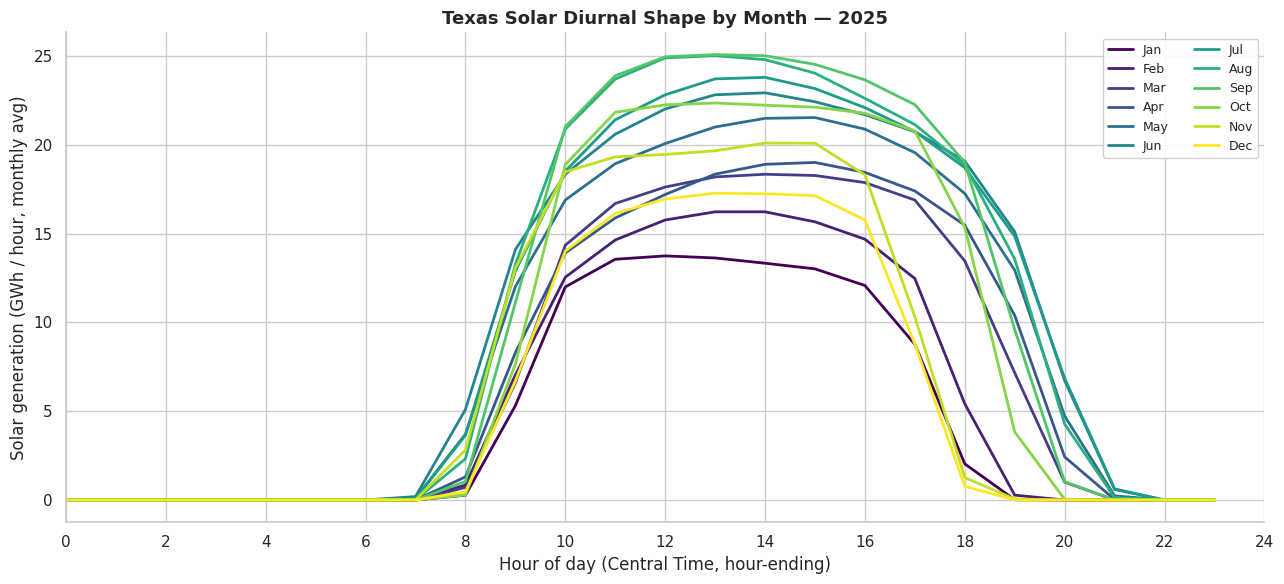

Solar peak hour (GWh at peak) by month:
  Jan: hour 12 → 13.74 GWh/h
  Feb: hour 13 → 16.22 GWh/h
  Mar: hour 14 → 18.34 GWh/h
  Apr: hour 15 → 19.00 GWh/h
  May: hour 15 → 21.53 GWh/h
  Jun: hour 14 → 22.92 GWh/h
  Jul: hour 14 → 23.79 GWh/h
  Aug: hour 13 → 25.01 GWh/h
  Sep: hour 13 → 25.07 GWh/h
  Oct: hour 13 → 22.35 GWh/h
  Nov: hour 14 → 20.09 GWh/h
  Dec: hour 13 → 17.27 GWh/h


In [8]:
solar_hourly = hourly['solar'].copy() / 1e3   # → GWh/hour

# Average GWh/hour by (month, hour-of-day)
pivot = solar_hourly.groupby([hourly['month'], hourly['hour']]).mean().unstack('hour')
# ensure columns 0..23 in order
pivot = pivot.reindex(columns=range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.get_cmap('viridis')
for i, month in enumerate(range(1, 13)):
    vals = pivot.loc[month]
    ax.plot(vals.index, vals.values,
            color=cmap(i / 11), linewidth=2,
            label=MONTH_NAMES[month - 1])

ax.set_xlabel('Hour of day (Central Time, hour-ending)')
ax.set_ylabel('Solar generation (GWh / hour, monthly avg)')
ax.set_title('Texas Solar Diurnal Shape by Month — 2025',
             fontsize=13, fontweight='bold')
ax.set_xticks(range(0, 25, 2))
ax.set_xlim(0, 24)
ax.legend(loc='upper right', ncol=2, fontsize=9, framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

# peak hour per month
print('Solar peak hour (GWh at peak) by month:')
for month in range(1, 13):
    row = pivot.loc[month]
    peak_h = row.idxmax()
    peak_v = row.max()
    print(f'  {MONTH_NAMES[month-1]}: hour {peak_h:2d} → {peak_v:5.2f} GWh/h')

## 7. Monthly emissions intensity

Which months are the cleanest per-MWh and which are the dirtiest?

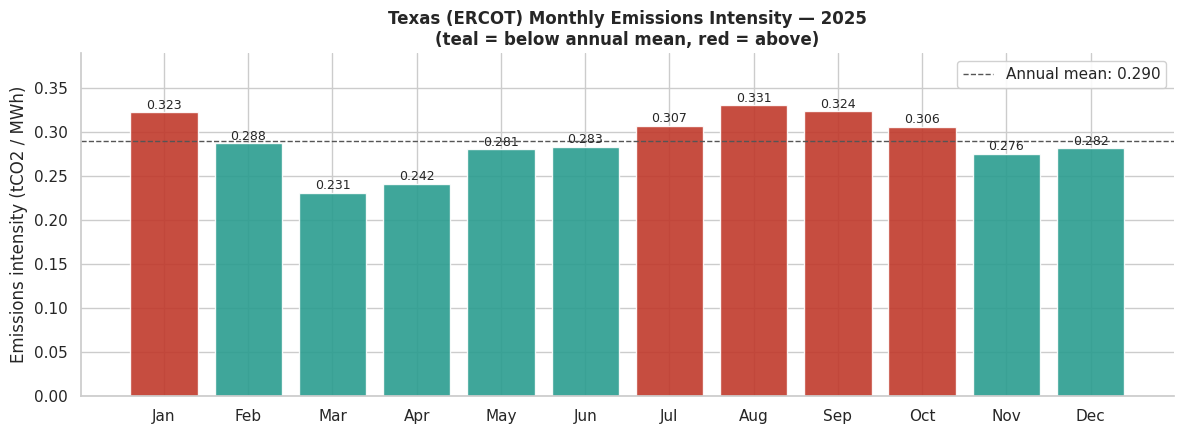


Monthly intensity ranking (cleanest first):
   1. Mar: 0.231 tCO2/MWh
   2. Apr: 0.242 tCO2/MWh
   3. Nov: 0.276 tCO2/MWh
   4. May: 0.281 tCO2/MWh
   5. Dec: 0.282 tCO2/MWh
   6. Jun: 0.283 tCO2/MWh
   7. Feb: 0.288 tCO2/MWh
   8. Oct: 0.306 tCO2/MWh
   9. Jul: 0.307 tCO2/MWh
  10. Jan: 0.323 tCO2/MWh
  11. Sep: 0.324 tCO2/MWh
  12. Aug: 0.331 tCO2/MWh


In [9]:
monthly_ei = daily.groupby('month')['intensity'].mean()
annual_mean = daily['intensity'].mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = ['#C0392B' if v > annual_mean else '#2A9D8F' for v in monthly_ei.values]
bars = ax.bar(MONTH_NAMES, monthly_ei.values, color=colors, alpha=0.9)
for bar, val in zip(bars, monthly_ei.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.004,
            f'{val:.3f}', ha='center', fontsize=9)

ax.axhline(annual_mean, color='#555', linestyle='--', linewidth=1,
           label=f'Annual mean: {annual_mean:.3f}')
ax.set_ylabel('Emissions intensity (tCO2 / MWh)')
ax.set_title('Texas (ERCOT) Monthly Emissions Intensity — 2025\n(teal = below annual mean, red = above)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, monthly_ei.max() * 1.18)
ax.legend(loc='upper right', framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()

print('\nMonthly intensity ranking (cleanest first):')
for i, (m, v) in enumerate(monthly_ei.sort_values().items(), 1):
    print(f'  {i:2d}. {MONTH_NAMES[m-1]}: {v:.3f} tCO2/MWh')

## Key findings (fill in after first run)

1. **The seasonal regimes are temperature-driven, not rainfall-driven.** Winter and summer are the high-demand corners; spring is when wind peaks.
2. **Summer peak is gas-CC heavy.** When AC load maxes, combined-cycle gas does the work — simple-cycle peakers fill the last notches of peak.
3. **Spring is the renewable moment.** March–May shows the highest wind share, and solar grows through the spring.
4. **Winter stress ≠ dirtiest month.** Look at the monthly intensity chart — the cleanest and dirtiest months may surprise you.
5. **Solar's duck curve widens in summer and narrows in winter.** The diurnal shape chart makes this visible in a way Edition 1 could never show.
6. **Compared to India:** India's cleanest month (August, monsoon) had an emissions intensity ~620 tCO2/GWh. Texas's *dirtiest* month probably still sits well below that.

→ Checkpoint before notebooks 05+ / art prototypes.